In [2]:
# IMPORTS

import json
import os
import pickle
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from tensorflow.keras.models import load_model
from pytorch_tabnet.tab_model import TabNetClassifier

import warnings
warnings.filterwarnings("ignore")


In [3]:
# PATHS

root_path = Path.cwd().resolve()
if root_path.name == "notebooks":
    root_path = root_path.parent

data_dir = root_path / "data"
artifact_dir = root_path / "artifacts"
candidate_model_dir = artifact_dir / "model_candidates"
model_dir = root_path / "models"
result_dir = root_path / "results"
image_dir = root_path / "images"

for directory in [data_dir, artifact_dir, candidate_model_dir, model_dir, result_dir, image_dir]:
    directory.mkdir(parents=True, exist_ok=True)


In [4]:
# LOAD DATA

required_result_files = [
    "y_test.npy",
    "mlp_pred.npy",
    "gru_pred.npy",
    "bilstm_pred.npy",
    "tabnet_pred.npy",
    "ft_transformer_pred.npy",
    "tabtransformer_pred.npy",
    "mlp_prob.npy",
    "gru_prob.npy",
    "bilstm_prob.npy",
    "tabnet_prob.npy",
    "ft_transformer_prob.npy",
    "tabtransformer_prob.npy",
]
missing_result_files = [name for name in required_result_files if not (result_dir / name).exists()]
if missing_result_files:
    raise FileNotFoundError(
        "Missing training result artifacts: "
        + ", ".join(missing_result_files)
        + ". Run model_training.ipynb before result_analysis.ipynb."
    )

y_test = np.load(result_dir / "y_test.npy")

# Predictions
mlp_pred = np.load(result_dir / "mlp_pred.npy")
gru_pred = np.load(result_dir / "gru_pred.npy")
bilstm_pred = np.load(result_dir / "bilstm_pred.npy")
tabnet_pred = np.load(result_dir / "tabnet_pred.npy")
ft_transformer_pred = np.load(result_dir / "ft_transformer_pred.npy")
tabtransformer_pred = np.load(result_dir / "tabtransformer_pred.npy")

# Probabilities
mlp_prob = np.load(result_dir / "mlp_prob.npy")
gru_prob = np.load(result_dir / "gru_prob.npy")
bilstm_prob = np.load(result_dir / "bilstm_prob.npy")
tabnet_prob = np.load(result_dir / "tabnet_prob.npy")
ft_transformer_prob = np.load(result_dir / "ft_transformer_prob.npy")
tabtransformer_prob = np.load(result_dir / "tabtransformer_prob.npy")

In [5]:
# MODEL OUTPUT REGISTRY

model_outputs = {
    "MLP": {"pred": mlp_pred, "prob": mlp_prob},
    "GRU": {"pred": gru_pred, "prob": gru_prob},
    "BiLSTM": {"pred": bilstm_pred, "prob": bilstm_prob},
    "TabNet": {"pred": tabnet_pred, "prob": tabnet_prob},
    "FT-Transformer": {"pred": ft_transformer_pred, "prob": ft_transformer_prob},
    "TabTransformer": {"pred": tabtransformer_pred, "prob": tabtransformer_prob},
}

model_names = list(model_outputs.keys())

history_path = artifact_dir / "training_histories.pkl"
if os.path.exists(history_path):
    with open(history_path, "rb") as f:
        training_histories = pickle.load(f)
else:
    training_histories = {}


In [6]:
# EVALUATION FUNCTION

def evaluate_model(name, y_true, y_pred, y_prob):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    y_prob = np.clip(np.asarray(y_prob, dtype=float), 1e-7, 1 - 1e-7)

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    unique_prob = np.unique(np.round(y_prob, 8)).size

    if unique_prob <= 2:
        print(f"Warning: {name} probabilities look discrete/constant; check probability extraction.")

    return {
        "Model": name,
        "Fraud Precision": precision_score(y_true, y_pred, zero_division=0),
        "Fraud Recall": recall_score(y_true, y_pred, zero_division=0),
        "Fraud F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"],
        "Log Loss": log_loss(y_true, y_prob, labels=[0, 1]),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "True Positives": int(tp),
        "True Negatives": int(tn),
        "Unique Probabilities": unique_prob,
    }


In [7]:
# JSON SERIALIZATION HELPER

def json_default(value):
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"Object of type {type(value).__name__} is not JSON serializable")


In [8]:
# MODEL EVALUATION

results = []

for name, output in model_outputs.items():
    results.append(
        evaluate_model(
            name,
            y_test,
            output["pred"],
            output["prob"],
        )
    )


In [9]:
# CREATE COMPARISON TABLE

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    by=["Fraud F1", "Fraud Recall", "Fraud Precision", "PR-AUC", "ROC-AUC"],
    ascending=False,
)

metrics_path = result_dir / "model_metrics.csv"
metrics_json_path = result_dir / "model_metrics.json"
df_results.to_csv(metrics_path, index=False)
with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(df_results.to_dict(orient="records"), f, indent=2, default=json_default)

print("\n================ REALISTIC FRAUD MODEL COMPARISON ================\n")
print(df_results.to_string(index=False))
print("\nSaved metrics:", metrics_path)



================ REALISTIC FRAUD MODEL COMPARISON ================

         Model  Fraud Precision  Fraud Recall  Fraud F1  ROC-AUC   PR-AUC  Macro F1  Weighted F1  Log Loss  False Positives  False Negatives  True Positives  True Negatives  Unique Probabilities
           MLP         0.972200      0.965097  0.968635 0.998706 0.994943  0.981195     0.989568  0.030928               34               43            1189            6126                  7100
        BiLSTM         0.964955      0.961039  0.962993 0.997502 0.994431  0.977805     0.987679  0.043626               43               48            1184            6117                  6844
           GRU         0.967105      0.954545  0.960784 0.997421 0.993792  0.976501     0.986979  0.046329               40               56            1176            6120                  6846
        TabNet         0.922747      0.872565  0.896955 0.992250 0.966722  0.938507     0.966209  0.131897               90              157           

In [10]:
# CONFUSION MATRIX FUNCTION

def plot_conf_matrix(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

    plt.figure(figsize=(6, 5))
    plt.title(f"Confusion Matrix - {name}")
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()

    plt.xticks([0, 1], ["Fraud\n(Positive)", "Legitimate\n(Negative)"])
    plt.yticks([0, 1], ["Fraud\n(Positive)", "Legitimate\n(Negative)"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i][j]),
                     ha="center", va="center", color="black", fontsize=12)

    plt.tight_layout()
    fig_path = image_dir / f"confusion_matrix_{name.replace(' ', '_')}.png"
    plt.savefig(fig_path, dpi=300)
    print(f"Saved confusion matrix: {fig_path}")
    plt.show()

Saved confusion matrix: C:\Project\Transactional-Fraud-Detection\images\confusion_matrix_MLP.png


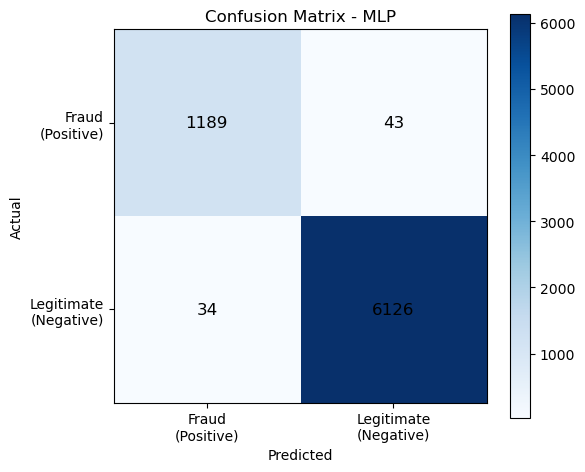

Saved confusion matrix: C:\Project\Transactional-Fraud-Detection\images\confusion_matrix_GRU.png


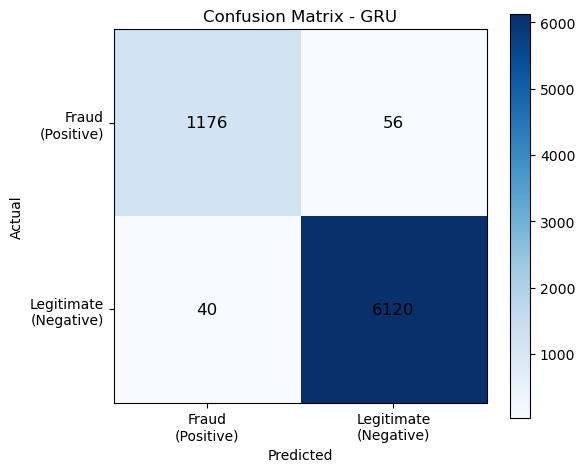

Saved confusion matrix: C:\Project\Transactional-Fraud-Detection\images\confusion_matrix_BiLSTM.png


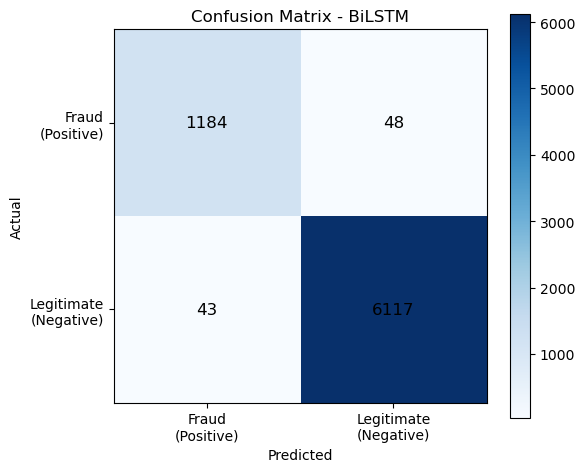

Saved confusion matrix: C:\Project\Transactional-Fraud-Detection\images\confusion_matrix_TabNet.png


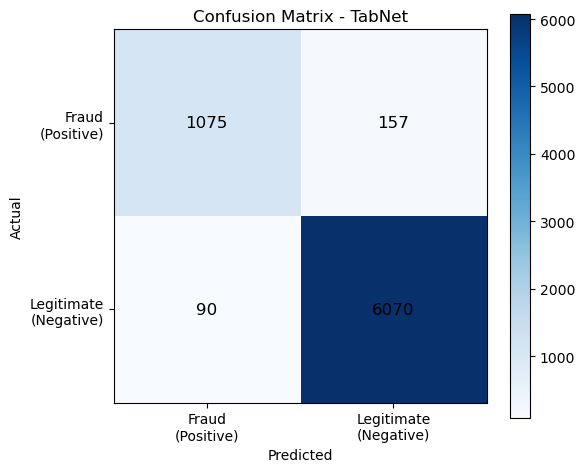

Saved confusion matrix: C:\Project\Transactional-Fraud-Detection\images\confusion_matrix_FT-Transformer.png


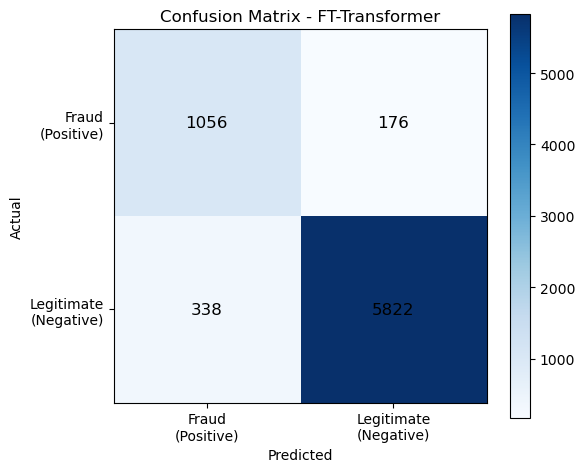

Saved confusion matrix: C:\Project\Transactional-Fraud-Detection\images\confusion_matrix_TabTransformer.png


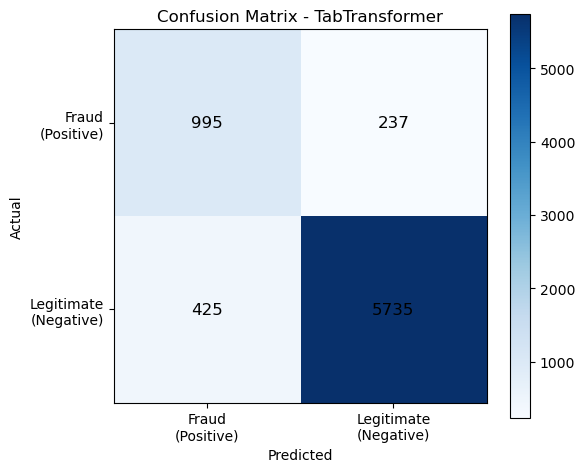

In [11]:
# PLOT ALL MODELS

plot_conf_matrix("MLP", y_test, mlp_pred)
plot_conf_matrix("GRU", y_test, gru_pred)
plot_conf_matrix("BiLSTM", y_test, bilstm_pred)
plot_conf_matrix("TabNet", y_test, tabnet_pred)
plot_conf_matrix("FT-Transformer", y_test, ft_transformer_pred)
plot_conf_matrix("TabTransformer", y_test, tabtransformer_pred)

Saved ROC comparison: C:\Project\Transactional-Fraud-Detection\images\roc_comparison.png


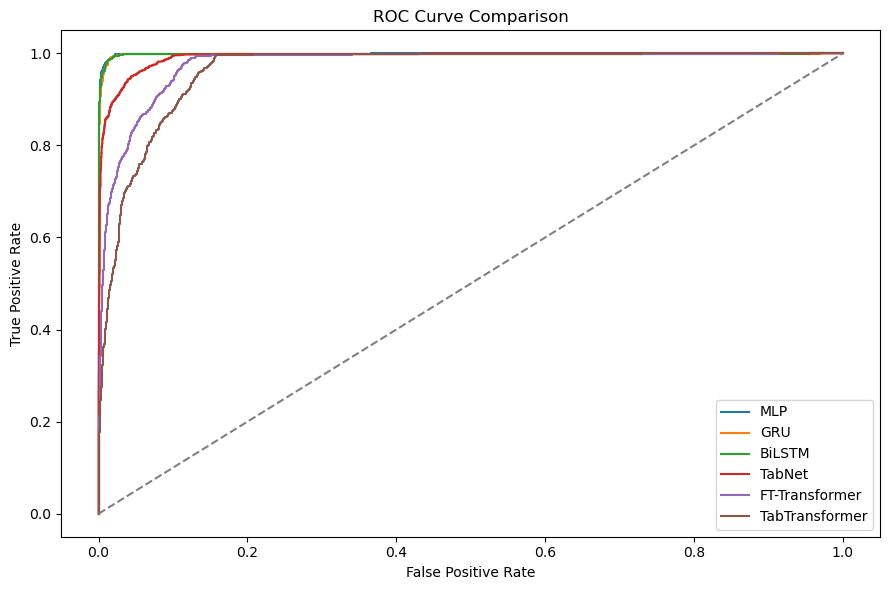

Saved PR comparison: C:\Project\Transactional-Fraud-Detection\images\pr_comparison.png


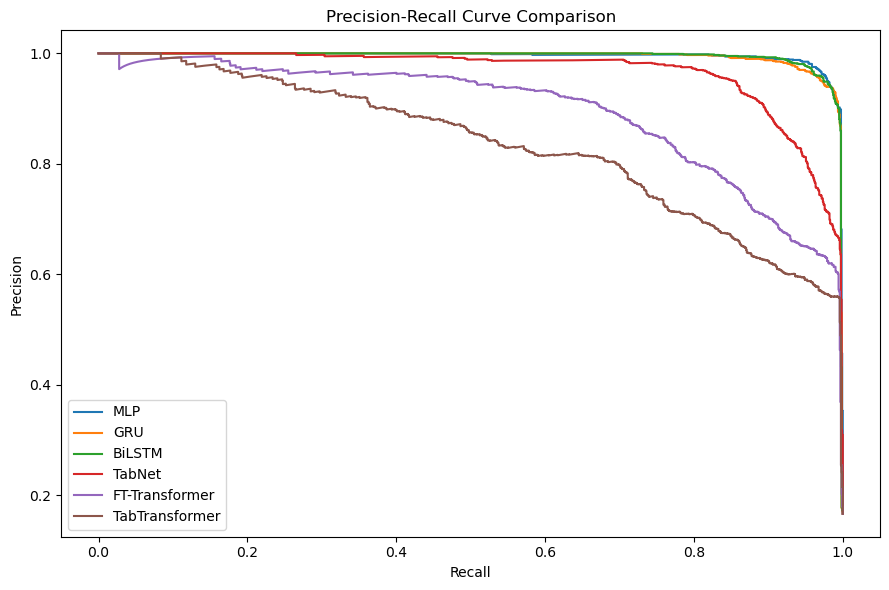

In [12]:
# ROC AND PRECISION-RECALL CURVES

plt.figure(figsize=(9, 6))
plt.title("ROC Curve Comparison")

for name, output in model_outputs.items():
    fpr, tpr, _ = roc_curve(y_test, output["prob"])
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
roc_path = image_dir / "roc_comparison.png"
plt.savefig(roc_path, dpi=300)
print(f"Saved ROC comparison: {roc_path}")
plt.show()

plt.figure(figsize=(9, 6))
plt.title("Precision-Recall Curve Comparison")

for name, output in model_outputs.items():
    precision, recall, _ = precision_recall_curve(y_test, output["prob"])
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
pr_path = image_dir / "pr_comparison.png"
plt.savefig(pr_path, dpi=300)
print(f"Saved PR comparison: {pr_path}")
plt.show()

Saved loss curve: C:\Project\Transactional-Fraud-Detection\images\loss_curve_MLP.png


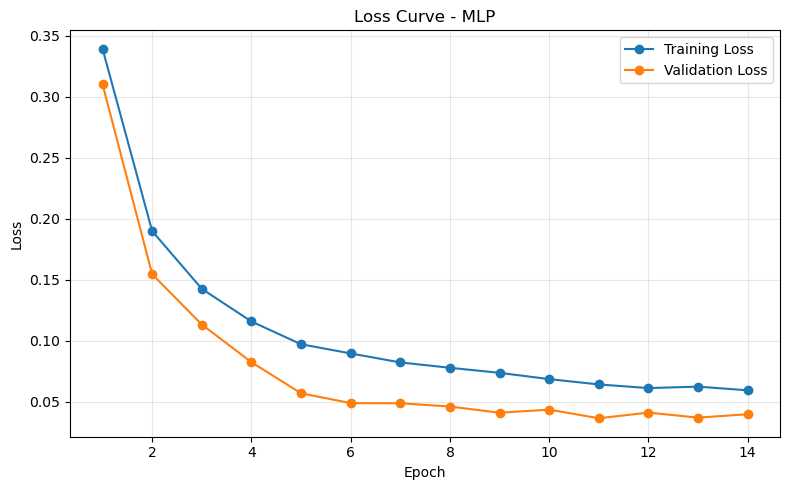

Saved loss curve: C:\Project\Transactional-Fraud-Detection\images\loss_curve_GRU.png


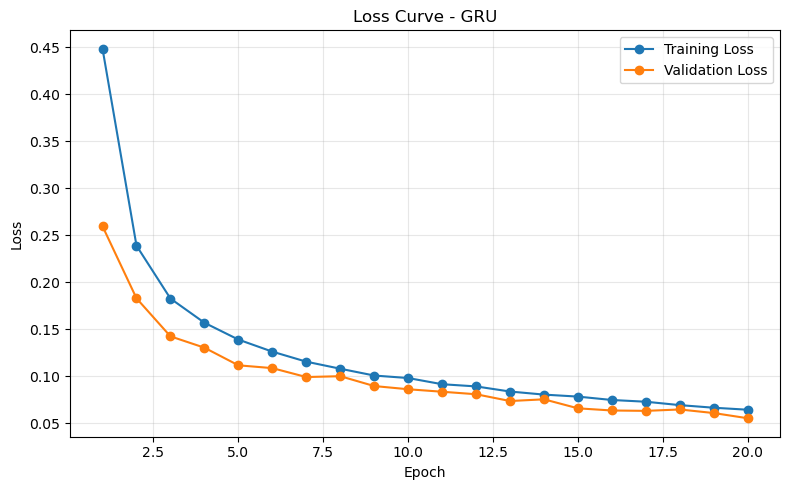

Saved loss curve: C:\Project\Transactional-Fraud-Detection\images\loss_curve_BiLSTM.png


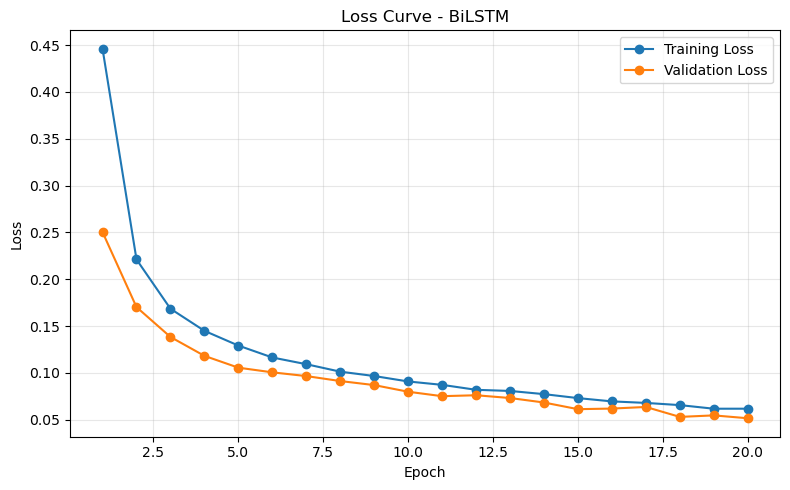

Saved loss curve: C:\Project\Transactional-Fraud-Detection\images\loss_curve_TabNet.png


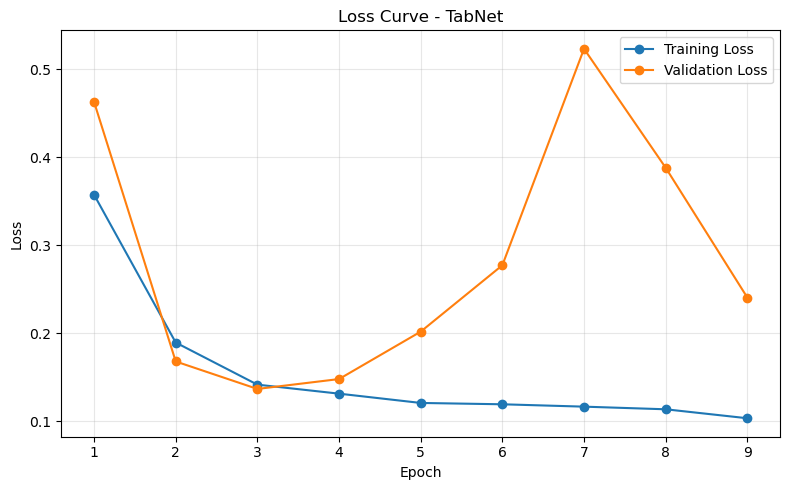

Saved loss curve: C:\Project\Transactional-Fraud-Detection\images\loss_curve_FT-Transformer.png


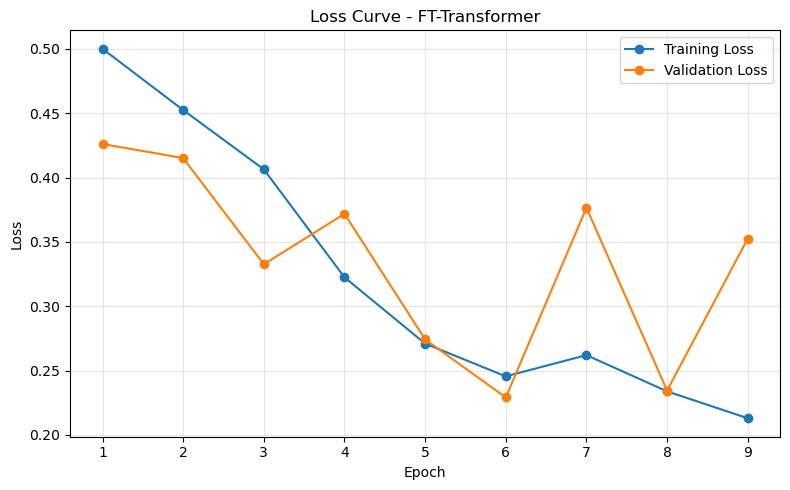

Saved loss curve: C:\Project\Transactional-Fraud-Detection\images\loss_curve_TabTransformer.png


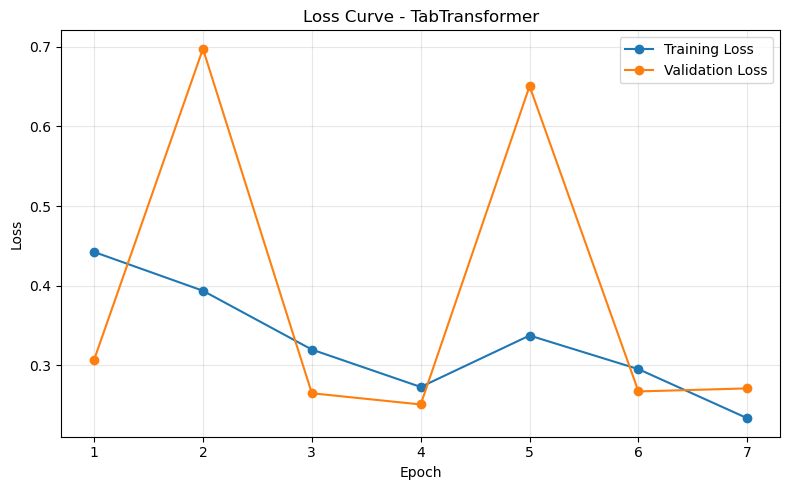

In [13]:
# LOSS CURVES

def get_history_dict(history_obj):
    if history_obj is None:
        return None

    if hasattr(history_obj, "history"):
        history_obj = history_obj.history

    if isinstance(history_obj, dict):
        return history_obj

    return None


def get_history_series(history, candidates):
    for key in candidates:
        values = history.get(key)
        if values is not None:
            return key, np.asarray(values, dtype=float)

    return None, None


def plot_loss_curves(model_names, training_histories):
    plotted = False

    for name in model_names:
        history = get_history_dict(training_histories.get(name))

        if not history:
            print(f"Loss history unavailable for {name}; skipping loss curve.")
            continue

        train_key, train_loss = get_history_series(history, ["loss", "train_loss"])
        val_key, val_loss = get_history_series(
            history,
            ["val_loss", "val_0_logloss", "valid_logloss", "validation_logloss"],
        )

        if train_loss is None:
            print(f"Training loss unavailable for {name}; skipping loss curve.")
            continue

        epochs = np.arange(1, len(train_loss) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, train_loss, marker="o", label="Training Loss")

        if val_loss is not None:
            val_epochs = np.arange(1, len(val_loss) + 1)
            plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
        elif name == "TabNet" and "val_0_auc" in history:
            print(
                "TabNet validation loss is missing in the saved history. "
                "Re-run model_training.ipynb after this fix to record val_0_logloss."
            )

        plt.title(f"Loss Curve - {name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        loss_path = image_dir / f"loss_curve_{name.replace(' ', '_')}.png"
        plt.savefig(loss_path, dpi=300)
        print(f"Saved loss curve: {loss_path}")
        plt.show()
        plotted = True

    if not plotted:
        print(
            "No saved training histories were found. "
            "Run model_training.ipynb before result_analysis.ipynb to generate loss curves."
        )



plot_loss_curves(model_names, training_histories)

Saved false positive/negative counts: C:\Project\Transactional-Fraud-Detection\images\false_positive_negative_counts.png


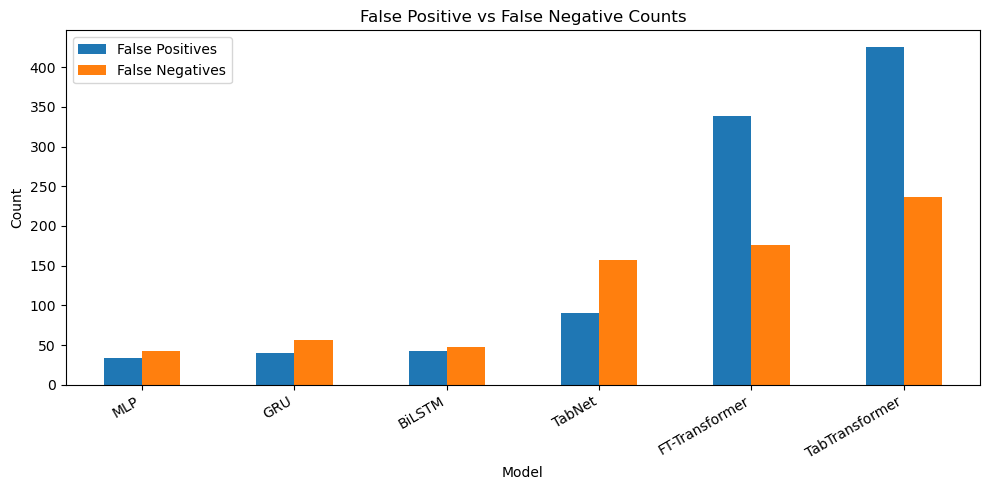

Saved fraud operating metrics: C:\Project\Transactional-Fraud-Detection\images\fraud_operating_metrics.png


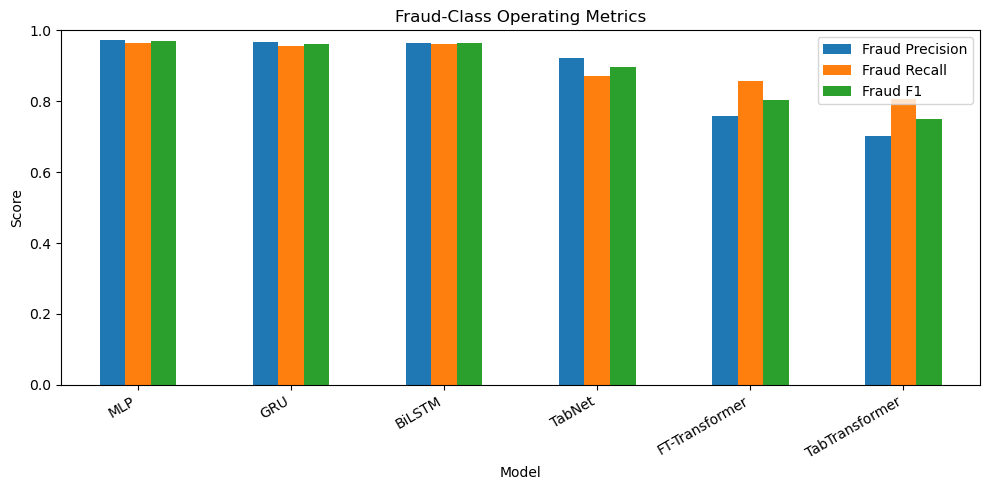

In [14]:
# FRAUD ERROR ANALYSIS GRAPHS

df_error = df_results.set_index("Model").loc[model_names].reset_index()

ax = df_error.plot(
    x="Model",
    y=["False Positives", "False Negatives"],
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("False Positive vs False Negative Counts")
ax.set_xlabel("Model")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fp_fn_path = image_dir / "false_positive_negative_counts.png"
plt.savefig(fp_fn_path, dpi=300)
print(f"Saved false positive/negative counts: {fp_fn_path}")
plt.show()

ax = df_error.plot(
    x="Model",
    y=["Fraud Precision", "Fraud Recall", "Fraud F1"],
    kind="bar",
    figsize=(10, 5),
)
ax.set_title("Fraud-Class Operating Metrics")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
metrics_path = image_dir / "fraud_operating_metrics.png"
plt.savefig(metrics_path, dpi=300)
print(f"Saved fraud operating metrics: {metrics_path}")
plt.show()

Saved PR-AUC comparison: C:\Project\Transactional-Fraud-Detection\images\pr_auc_comparison.png


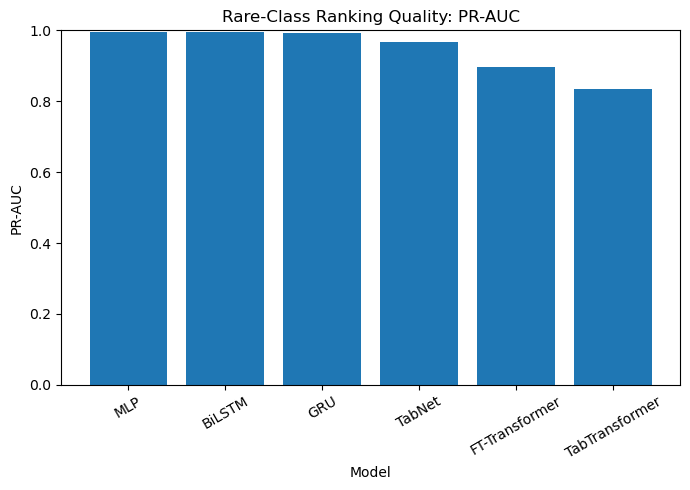

In [15]:
# PROBABILITY AND FRAUD DETECTION BEHAVIOR COMPARISON

comparison_cols = [
    "Model",
    "Log Loss",
    "Fraud F1",
    "Fraud Recall",
    "Fraud Precision",
    "PR-AUC",
    "ROC-AUC",
    "False Positives",
    "False Negatives",
]

df_loss_error = df_results[comparison_cols].sort_values(
    by=["Fraud F1", "Fraud Recall", "PR-AUC"],
    ascending=False,
)

plt.figure(figsize=(7, 5))

plt.bar(df_loss_error["Model"], df_loss_error["PR-AUC"])
plt.title("Rare-Class Ranking Quality: PR-AUC")
plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=30)

plt.tight_layout()
pr_auc_path = image_dir / "pr_auc_comparison.png"
plt.savefig(pr_auc_path, dpi=300)
print(f"Saved PR-AUC comparison: {pr_auc_path}")
plt.show()

Saved F1 score comparison: C:\Project\Transactional-Fraud-Detection\images\f1_score_comparison.png


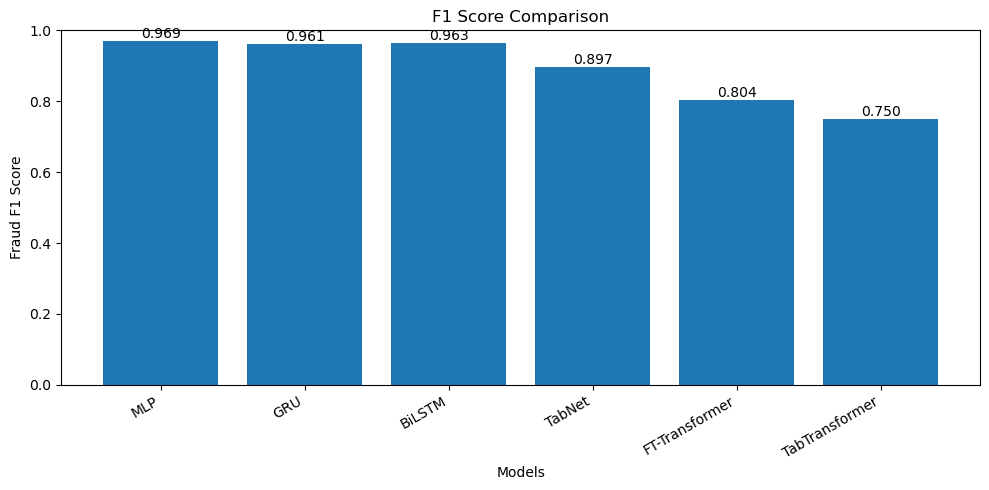

In [16]:
# F1 SCORE COMPARISON

plt.figure(figsize=(10, 5))
plt.title("F1 Score Comparison")

f1_table = df_results.set_index("Model").loc[model_names].reset_index()
bars = plt.bar(f1_table["Model"], f1_table["Fraud F1"])

plt.xlabel("Models")
plt.ylabel("Fraud F1 Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
f1_score_path = image_dir / "f1_score_comparison.png"
plt.savefig(f1_score_path, dpi=300)
print(f"Saved F1 score comparison: {f1_score_path}")
plt.show()

In [17]:
# FINAL INSIGHT AND BEST MODEL SAVE

best_model = df_results.sort_values(
    by=["Fraud F1", "Fraud Recall", "Fraud Precision", "PR-AUC", "ROC-AUC"],
    ascending=False,
).iloc[0]

lowest_log_loss_model = df_results.sort_values(
    by=["Log Loss", "PR-AUC"],
    ascending=[True, False],
).iloc[0]

print("\n=========================")
print("FINAL CONCLUSION")
print("=========================")

print("Best Fraud F1 Model       :", best_model["Model"])
print("Fraud F1 Score            :", round(best_model["Fraud F1"], 4))
print("Fraud Recall              :", round(best_model["Fraud Recall"], 4))
print("Fraud Precision           :", round(best_model["Fraud Precision"], 4))
print("PR-AUC Score              :", round(best_model["PR-AUC"], 4))
print("ROC-AUC Score             :", round(best_model["ROC-AUC"], 4))
print("Lowest Log Loss Model     :", lowest_log_loss_model["Model"], round(lowest_log_loss_model["Log Loss"], 4))

MODEL_VARIABLE_NAMES = {
    "MLP": "mlp",
    "GRU": "gru",
    "BiLSTM": "bilstm",
    "TabNet": "tabnet",
    "FT-Transformer": "ft_transformer",
    "TabTransformer": "tabtransformer",
}

CANDIDATE_MODEL_PATHS = {
    "MLP": candidate_model_dir / "mlp_model.keras",
    "GRU": candidate_model_dir / "gru_model.keras",
    "BiLSTM": candidate_model_dir / "bilstm_model.keras",
    "TabNet": candidate_model_dir / "tabnet_model.zip",
    "FT-Transformer": candidate_model_dir / "ft_transformer_model.keras",
    "TabTransformer": candidate_model_dir / "tabtransformer_model.keras",
}

MODEL_ARTIFACTS_TO_REMOVE = [
    "mlp_model.keras",
    "gru_model.keras",
    "bilstm_model.keras",
    "ft_transformer_model.keras",
    "tabtransformer_model.keras",
    "tabnet_model.zip",
    "best_model.keras",
    "best_model.zip",
    "best_model_metadata.json",
]


def load_decision_thresholds():
    thresholds_path = artifact_dir / "decision_thresholds.json"
    if thresholds_path.exists():
        with open(thresholds_path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def remove_existing_model_artifacts():
    for artifact_name in MODEL_ARTIFACTS_TO_REMOVE:
        artifact_path = model_dir / artifact_name
        if artifact_path.exists():
            artifact_path.unlink()


def remove_candidate_model_artifacts():
    for candidate_artifact in candidate_model_dir.glob("*"):
        if candidate_artifact.is_file():
            candidate_artifact.unlink()


def load_candidate_model(best_model_name):
    candidate_path = CANDIDATE_MODEL_PATHS[best_model_name]
    if not candidate_path.exists():
        raise FileNotFoundError(
            f"Missing candidate artifact for {best_model_name}: {candidate_path}. "
            "Run model_training.ipynb before result_analysis.ipynb."
        )

    if best_model_name == "TabNet":
        candidate_model = TabNetClassifier()
        candidate_model.load_model(str(candidate_path))
        return candidate_model

    return load_model(candidate_path)


def save_selected_best_model(best_model_row):
    best_model_name = str(best_model_row["Model"])
    model_variable_name = MODEL_VARIABLE_NAMES[best_model_name]
    selected_model = globals().get(model_variable_name)

    if selected_model is None:
        selected_model = load_candidate_model(best_model_name)

    remove_existing_model_artifacts()

    if best_model_name == "TabNet":
        artifact_path = model_dir / "best_model.zip"
        selected_model.save_model(str(model_dir / "best_model"))
        model_family = "tabnet"
    else:
        artifact_path = model_dir / "best_model.keras"
        selected_model.save(artifact_path)
        model_family = "keras"

    decision_thresholds = load_decision_thresholds()
    metadata = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "model_name": best_model_name,
        "model_family": model_family,
        "artifact_path": str(artifact_path.relative_to(root_path)),
        "selection_criteria": ["Fraud F1", "Fraud Recall", "Fraud Precision", "PR-AUC", "ROC-AUC"],
        "selection_metrics": best_model_row.to_dict(),
        "decision_threshold": decision_thresholds.get(best_model_name, {}),
    }

    metadata_path = model_dir / "best_model_metadata.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, default=json_default)

    legacy_best_model_txt = result_dir / "best_model.txt"
    if legacy_best_model_txt.exists():
        legacy_best_model_txt.unlink()

    remove_candidate_model_artifacts()

    return artifact_path, metadata_path


best_model_artifact_path, best_model_metadata_path = save_selected_best_model(best_model)

print("Saved best model artifact  :", best_model_artifact_path)
print("Saved best model metadata  :", best_model_metadata_path)



FINAL CONCLUSION
Best Fraud F1 Model       : MLP
Fraud F1 Score            : 0.9686
Fraud Recall              : 0.9651
Fraud Precision           : 0.9722
PR-AUC Score              : 0.9949
ROC-AUC Score             : 0.9987
Lowest Log Loss Model     : MLP 0.0309
Saved best model artifact  : C:\Project\Transactional-Fraud-Detection\models\best_model.keras
Saved best model metadata  : C:\Project\Transactional-Fraud-Detection\models\best_model_metadata.json
